In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from google.colab import files

uploaded = files.upload()

Saving sales_data.csv to sales_data.csv


In [3]:
df = pd.read_csv("sales_data.csv")

# Display first 5 rows
df.head()

,CustomerID,ProductCategory,Quantity,Price,OrderDate
0,C001,Electronics,2,500,2025-01-05
1,C002,Furniture,1,800,2025-01-08
2,C003,Clothing,5,40,2025-01-10
3,C004,Electronics,1,1200,2025-01-15
4,C005,Groceries,10,15,2025-01-20


In [4]:
print("Dataset Shape:", df.shape)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (59, 5)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   CustomerID       59 non-null     object
 1   ProductCategory  59 non-null     object
 2   Quantity         59 non-null     int64 
 3   Price            59 non-null     int64 
 4   OrderDate        59 non-null     object
dtypes: int64(2), object(3)
memory usage: 2.4+ KB
None

Missing Values:
CustomerID         0
ProductCategory    0
Quantity           0
Price              0
OrderDate          0
dtype: int64


In [5]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Fill missing values
df.fillna({
    "CustomerID":"Unknown",
    "ProductCategory":"Unknown",
    "Quantity":0,
    "Price":0
}, inplace=True)

# Convert date column
df["OrderDate"] = pd.to_datetime(df["OrderDate"])

print("Data cleaned successfully!")

Data cleaned successfully!


In [6]:
df["Revenue"] = df["Quantity"] * df["Price"]

df.head()

,CustomerID,ProductCategory,Quantity,Price,OrderDate,Revenue
0,C001,Electronics,2,500,2025-01-05,1000
1,C002,Furniture,1,800,2025-01-08,800
2,C003,Clothing,5,40,2025-01-10,200
3,C004,Electronics,1,1200,2025-01-15,1200
4,C005,Groceries,10,15,2025-01-20,150


In [7]:
category_revenue = df.groupby("ProductCategory")["Revenue"].sum()

print(category_revenue)

ProductCategory
Clothing        2929
Electronics    26050
Furniture      16550
Groceries       3767
Name: Revenue, dtype: int64


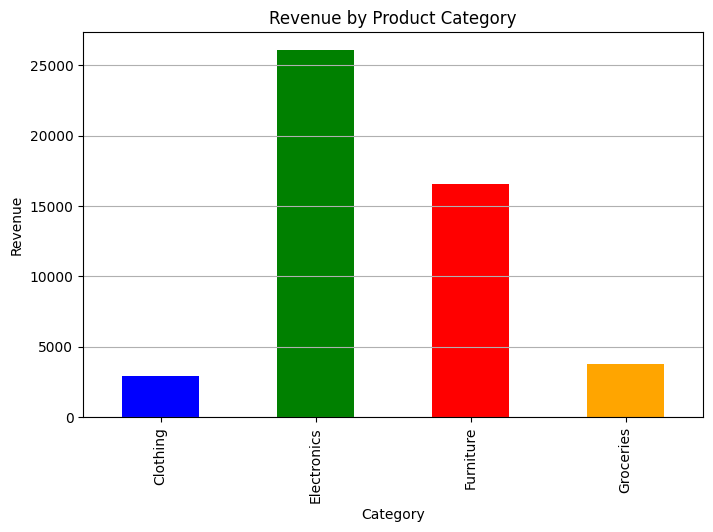

In [8]:
plt.figure(figsize=(8,5))

category_revenue.plot(kind='bar', color=['blue','green','red','orange'])

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.grid(axis='y')
plt.show()

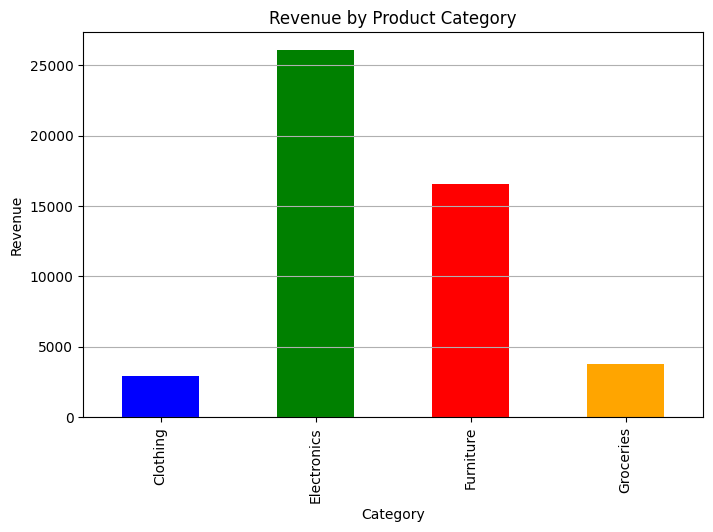

In [9]:
plt.figure(figsize=(8,5))

category_revenue.plot(kind='bar', color=['blue','green','red','orange'])

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.grid(axis='y')
plt.show()

In [11]:
top_customers = df.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False).head(10)

print(top_customers)

CustomerID
C002    6900
C001    6380
C008    5688
C007    5468
C004    5460
C005    4535
C003    4150
C006    3938
C009    3652
C010    3125
Name: Revenue, dtype: int64


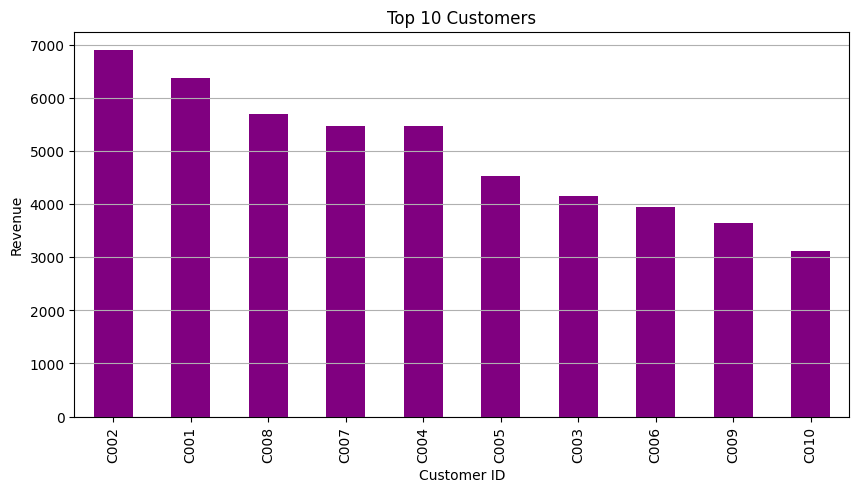

In [12]:
plt.figure(figsize=(10,5))

top_customers.plot(kind='bar', color='purple')

plt.title("Top 10 Customers")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")

plt.grid(axis='y')
plt.show()

In [13]:
df["Month"] = df["OrderDate"].dt.to_period("M")

monthly_sales = df.groupby("Month")["Revenue"].sum()

monthly_sales

,Revenue
Month,
2025-01,3350
2025-02,3310
2025-03,4120
2025-04,4366
2025-05,4800
2025-06,2934
2025-07,4270
2025-08,3875
2025-09,4045


In [14]:
print("========== Revenue by Category ==========")
print(category_revenue)

print("\n========== Top 10 Customers ==========")
print(top_customers)

print("\n========== Monthly Sales ==========")
print(monthly_sales)

========== Revenue by Category ==========
ProductCategory
Clothing        2929
Electronics    26050
Furniture      16550
Groceries       3767
Name: Revenue, dtype: int64

========== Top 10 Customers ==========
CustomerID
C002    6900
C001    6380
C008    5688
C007    5468
C004    5460
C005    4535
C003    4150
C006    3938
C009    3652
C010    3125
Name: Revenue, dtype: int64

========== Monthly Sales ==========
Month
2025-01    3350
2025-02    3310
2025-03    4120
2025-04    4366
2025-05    4800
2025-06    2934
2025-07    4270
2025-08    3875
2025-09    4045
2025-10    4778
2025-11    4360
2025-12    5088
Freq: M, Name: Revenue, dtype: int64
